In [ ]:
!git clone https://github.com/Aishwarya-93/Deepfake-Detection-KYC.git

Cloning into 'Deepfake-Detection-KYC'...
remote: Enumerating objects: 101, done.
remote: Counting objects: 100% (101/101), done.
remote: Compressing objects: 100% (81/81), done.
remote: Total 101 (delta 47), reused 59 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (101/101), 36.56 KiB | 1.41 MiB/s, done.
Resolving deltas: 100% (47/47), done.


In [ ]:
%cd Deepfake-Detection-KYC

/content/Deepfake-Detection-KYC


In [ ]:
!ls

data  environment.yml  outputs	      README.md  requirements.txt
docs  notebooks        presentations  reports	 src


In [ ]:
!touch src/preprocessing/image_preprocessing.py

In [ ]:
!ls src/preprocessing

image_preprocessing.py	read_metadata.py
inspect_dataset.py	validate_metadata.py


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
!pip install opencv-python

In [ ]:
 !ls data/raw

In [ ]:
!ls data/raw

In [ ]:
!ls data/raw/FaceForensics++_C23

ls: cannot access 'data/raw/FaceForensics++_C23': No such file or directory


In [ ]:
!find data/raw/FaceForensics++_C23/original -type f | head

find: ‘data/raw/FaceForensics++_C23/original’: No such file or directory


In [ ]:
!find data -maxdepth 3

data
data/processed
data/processed/.gitkeep
data/raw
data/raw/.gitkeep
data/sample
data/sample/.gitkeep
data/metadata
data/metadata/.gitkeep


In [ ]:
# Clone repository

import os

os.chdir("/content")

!rm -rf Deepfake-Detection-KYC

!git clone https://github.com/Aishwarya-93/Deepfake-Detection-KYC.git

%cd Deepfake-Detection-KYC

Cloning into 'Deepfake-Detection-KYC'...
remote: Enumerating objects: 106, done.
remote: Counting objects: 100% (106/106), done.
remote: Compressing objects: 100% (86/86), done.
remote: Total 106 (delta 50), reused 61 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (106/106), 37.72 KiB | 1.45 MiB/s, done.
Resolving deltas: 100% (50/50), done.
/content/Deepfake-Detection-KYC


In [ ]:
!pip install -q kaggle pandas numpy matplotlib opencv-python tqdm

In [ ]:
from pathlib import Path

print(Path.cwd())

!ls

/content/Deepfake-Detection-KYC
data  environment.yml  outputs	      README.md  requirements.txt
docs  notebooks        presentations  reports	 src


In [ ]:
!pip install -q kaggle pandas numpy matplotlib opencv-python tqdm

In [ ]:
import os
from getpass import getpass

print("Configure Kaggle")

os.environ["KAGGLE_USERNAME"] = input("Username: ")
os.environ["KAGGLE_KEY"] = getpass("API Token: ")

print("Kaggle configured")

Configure Kaggle
Username: preeshlahukare
API Token: ··········
Kaggle configured


In [ ]:
!kaggle datasets list -s faceforensics

ref                                                              title                                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------  --------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
greatgamedota/faceforensics                                      FaceForensics                                         724841395  2020-02-19 17:42:41.720000           4863         38  0.75             
xdxd003/ff-c23                                                   FaceForensics++ Dataset (C23)                       17891522096  2024-12-07 06:16:49.157000          51773        107  1                
hungle3401/faceforensics                                         FaceForensics++                                      2927395799  2024-02-13 04:35:27.907000           9020         26  0.3125  

In [ ]:
!kaggle datasets download -d xdxd003/ff-c23

Dataset URL: https://www.kaggle.com/datasets/xdxd003/ff-c23
License(s): other
100% 16.7G/16.7G [02:48<00:00, 106MB/s]



In [ ]:
!mkdir -p data/raw

In [ ]:
!unzip -q ff-c23.zip -d data/raw/

In [ ]:
!find data/raw -maxdepth 2 -type d

data/raw
data/raw/FaceForensics++_C23
data/raw/FaceForensics++_C23/original
data/raw/FaceForensics++_C23/Deepfakes
data/raw/FaceForensics++_C23/FaceShifter
data/raw/FaceForensics++_C23/FaceSwap
data/raw/FaceForensics++_C23/Face2Face
data/raw/FaceForensics++_C23/csv
data/raw/FaceForensics++_C23/DeepFakeDetection
data/raw/FaceForensics++_C23/NeuralTextures


In [ ]:
# Lab 08 – Image Preprocessing

## Objective
Prepare extracted image frames for deep learning by applying preprocessing techniques such as resizing, colour conversion, and normalization.

**Author:** Preesh

**Module:** Image Preprocessing

SyntaxError: invalid syntax (3858074422.py, line 4)

# Lab 08 – Image Preprocessing

## Objective
Prepare extracted image frames for deep learning by applying preprocessing techniques such as resizing, colour conversion, and normalization.

**Author:** Preesh

**Module:** Image Preprocessing

In [ ]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# ==========================================
# Dataset Paths
# ==========================================

DATASET_PATH = Path("data/raw/FaceForensics++_C23")
OUTPUT_PATH = Path("outputs/preprocessed_images")

OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

print("Dataset :", DATASET_PATH)
print("Output  :", OUTPUT_PATH)

Dataset : data/raw/FaceForensics++_C23
Output  : outputs/preprocessed_images


In [ ]:
# ==========================================
# Select One Sample Video
# ==========================================

video_files = sorted(DATASET_PATH.rglob("*.mp4"))

print("Total Videos:", len(video_files))

sample_video = video_files[0]

print("Sample Video:")
print(sample_video)

Total Videos: 7000
Sample Video:
data/raw/FaceForensics++_C23/DeepFakeDetection/01_02__meeting_serious__YVGY8LOK.mp4


In [ ]:
cap = cv2.VideoCapture(str(sample_video))

success, frame = cap.read()

cap.release()

print("Frame Loaded:", success)

print("Shape:", frame.shape)

Frame Loaded: True
Shape: (1080, 1920, 3)


In [ ]:
frame.shape

(1080, 1920, 3)

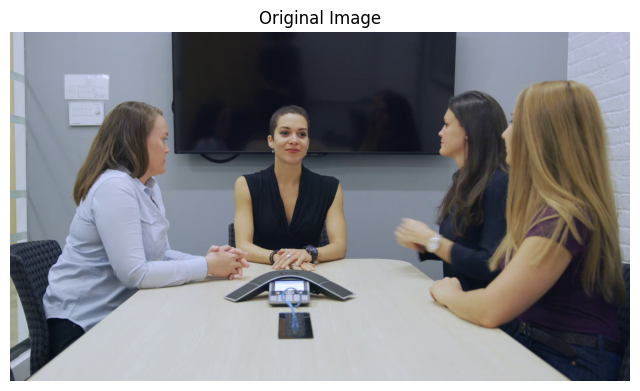

In [ ]:
# ==========================================
# Display Original Frame
# ==========================================

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,6))
plt.imshow(frame_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [ ]:
# ==========================================
# Resize Image
# ==========================================

TARGET_SIZE = (224, 224)

resized_image = cv2.resize(frame, TARGET_SIZE)

print("Original Shape :", frame.shape)
print("Resized Shape  :", resized_image.shape)

Original Shape : (1080, 1920, 3)
Resized Shape  : (224, 224, 3)


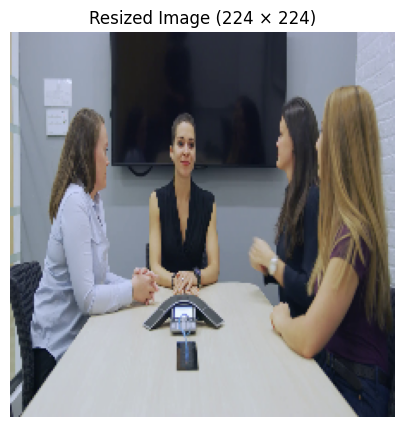

In [ ]:
resized_rgb = cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5,5))
plt.imshow(resized_rgb)
plt.title("Resized Image (224 × 224)")
plt.axis("off")
plt.show()

In [ ]:
# ==========================================
# Normalize Image
# ==========================================

normalized_image = resized_image.astype("float32") / 255.0

print("Data Type :", normalized_image.dtype)
print("Minimum   :", normalized_image.min())
print("Maximum   :", normalized_image.max())

Data Type : float32
Minimum   : 0.003921569
Maximum   : 1.0


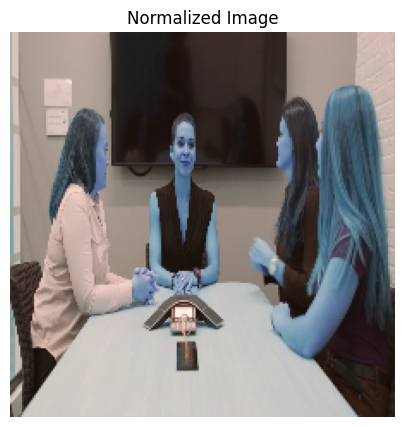

In [ ]:
plt.figure(figsize=(5,5))
plt.imshow(normalized_image)
plt.title("Normalized Image")
plt.axis("off")
plt.show()

In [ ]:
from src.preprocessing.image_preprocessing import resize_image, normalize_image

In [ ]:
# Test resize function

resized = resize_image(frame)

print("Resized Shape:", resized.shape)

Resized Shape: (224, 224, 3)


Minimum: 0.003921569
Maximum: 1.0
Datatype: float32


In [ ]:
from src.preprocessing.image_preprocessing import bgr_to_rgb

rgb_image = bgr_to_rgb(frame)

plt.figure(figsize=(5,5))
plt.imshow(rgb_image)
plt.title("RGB Image")
plt.axis("off")
plt.show()

ImportError: cannot import name 'bgr_to_rgb' from 'src.preprocessing.image_preprocessing' (/content/Deepfake-Detection-KYC/src/preprocessing/image_preprocessing.py)

In [ ]:
import importlib
import src.preprocessing.image_preprocessing

importlib.reload(src.preprocessing.image_preprocessing)

from src.preprocessing.image_preprocessing import (
    resize_image,
    normalize_image,
    bgr_to_rgb
)

In [ ]:
def bgr_to_rgb(image):
    """
    Convert OpenCV BGR image to RGB.
    """
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

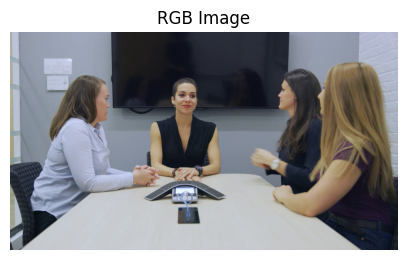

In [ ]:
rgb_image = bgr_to_rgb(frame)

plt.figure(figsize=(5,5))
plt.imshow(rgb_image)
plt.title("RGB Image")
plt.axis("off")
plt.show()

In [ ]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	src/preprocessing/image_preprocessing.py

nothing added to commit but untracked files present (use "git add" to track)


In [ ]:
!pwd
!find . -name "Lab_08_Image_Preprocessing.ipynb"

/content/Deepfake-Detection-KYC


In [ ]:
!git add src/preprocessing/image_preprocessing.py

In [ ]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   src/preprocessing/image_preprocessing.py



In [ ]:
!git commit -m "Add image preprocessing utilities"

Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@b4ab595e4a99.(none)')


In [ ]:
!git push origin main

fatal: could not read Username for 'https://github.com': No such device or address


In [ ]:
!git log --oneline -n 3

50a2db8 (HEAD -> main, origin/main, origin/HEAD) Added vedio_loader.py
a425c26 Complete Lab 4 metadata validation
b33c36c Added first validation function.


In [ ]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   src/preprocessing/image_preprocessing.py



In [ ]:
!git config --global user.name "Preeshhh"
!git config --global user.email "preeshlahukare77@gmail.com"

In [ ]:
!git commit -m "Add image preprocessing utilities"

[main a64566f] Add image preprocessing utilities
 1 file changed, 29 insertions(+)
 create mode 100644 src/preprocessing/image_preprocessing.py


In [ ]:
!git push origin main

fatal: could not read Username for 'https://github.com': No such device or address


In [ ]:
!git remote -v

origin	https://github.com/Aishwarya-93/Deepfake-Detection-KYC.git (fetch)
origin	https://github.com/Aishwarya-93/Deepfake-Detection-KYC.git (push)
